### **[Ridgeline Plots in Matplotlib](https://medium.com/data-science-collective/a12adf277c01)**

> Build stacked KDE plots from scratch and with joypy to show shape, skew, and spread across multiple groups

In [1]:
!pip install -qq joypy

In [2]:
import sys

import warnings
warnings.filterwarnings('ignore')

from IPython.display import display

import numpy as np
import pandas as pd

import matplotlib.cm as cm
import matplotlib.pyplot as plt

from scipy.stats import gaussian_kde

import joypy

IN_COLAB = 'google.colab' in sys.modules

np.random.seed(99)
np.set_printoptions(precision=4, suppress=True)

pd.set_option('display.float_format', lambda x: '%.4f' % x)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)
pd.set_option('display.precision', 4)
pd.set_option('display.colheader_justify', 'left')

%autosave 15

Autosaving every 15 seconds


In [3]:
formations = {
  'Vardan':   np.random.normal(0.29, 0.04, 120),
  'Kelvik':   np.random.normal(0.22, 0.05, 150),
  'Stenby':   np.random.normal(0.18, 0.04, 130),
  'Morvik':   np.random.normal(0.14, 0.03, 100),
  'Halvard':  np.random.beta(2, 8, 90) * 0.5,    # Skewed - mixed facies
  'Torven':   np.random.normal(0.20, 0.06, 140),
  'Elgfjord': np.random.normal(0.16, 0.03, 110),
}

# Clip to realistic porosity range
formations = {k: np.clip(v, 0, 0.5) for k, v in formations.items()}

display(formations)

{'Vardan': array([0.2843, 0.3723, 0.3013, 0.3432, 0.2838, 0.2872, 0.3202, 0.323 ,
        0.2855, 0.1953, 0.2833, 0.3174, 0.2909, 0.3082, 0.3008, 0.2326,
        0.3253, 0.2668, 0.2699, 0.3136, 0.2607, 0.3005, 0.2558, 0.2825,
        0.2751, 0.2715, 0.2573, 0.2882, 0.2949, 0.327 , 0.267 , 0.2921,
        0.3783, 0.3057, 0.3093, 0.3073, 0.2218, 0.2802, 0.2044, 0.3245,
        0.358 , 0.2688, 0.3605, 0.2451, 0.2423, 0.3121, 0.2574, 0.2701,
        0.3334, 0.251 , 0.2787, 0.2853, 0.3051, 0.3193, 0.2859, 0.2421,
        0.3304, 0.405 , 0.3228, 0.3124, 0.275 , 0.2799, 0.2344, 0.3147,
        0.2846, 0.3415, 0.2485, 0.3446, 0.2776, 0.2656, 0.2707, 0.2656,
        0.2065, 0.3156, 0.321 , 0.3411, 0.3182, 0.3162, 0.2229, 0.2973,
        0.2447, 0.2788, 0.3459, 0.2913, 0.1855, 0.2499, 0.2673, 0.281 ,
        0.3275, 0.3235, 0.3225, 0.2993, 0.2782, 0.2755, 0.3073, 0.3274,
        0.3521, 0.2937, 0.3018, 0.3494, 0.2465, 0.3228, 0.2585, 0.3538,
        0.3462, 0.3558, 0.3517, 0.3236, 0.2491, 0.3098

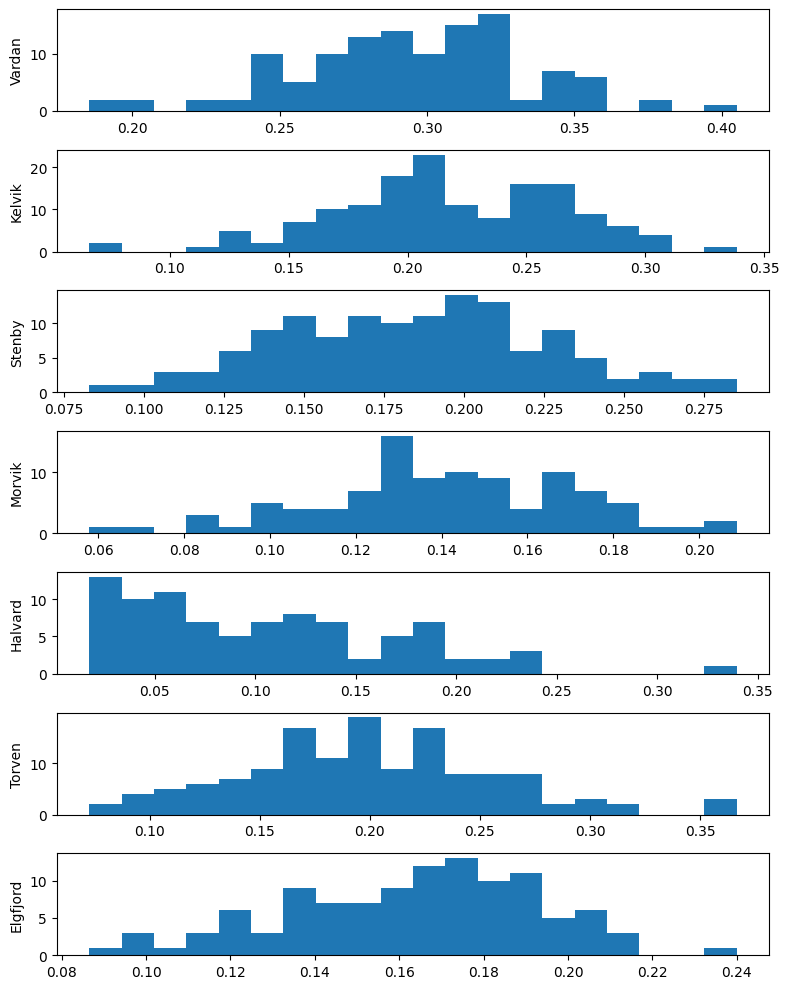

In [4]:
n = len(formations)
fig, axes = plt.subplots(n, 1, figsize=(8, 10))

for ax, (name, values) in zip(axes, formations.items()):
  ax.hist(values, bins=20)
  ax.set_ylabel(name)
plt.tight_layout()
plt.show()

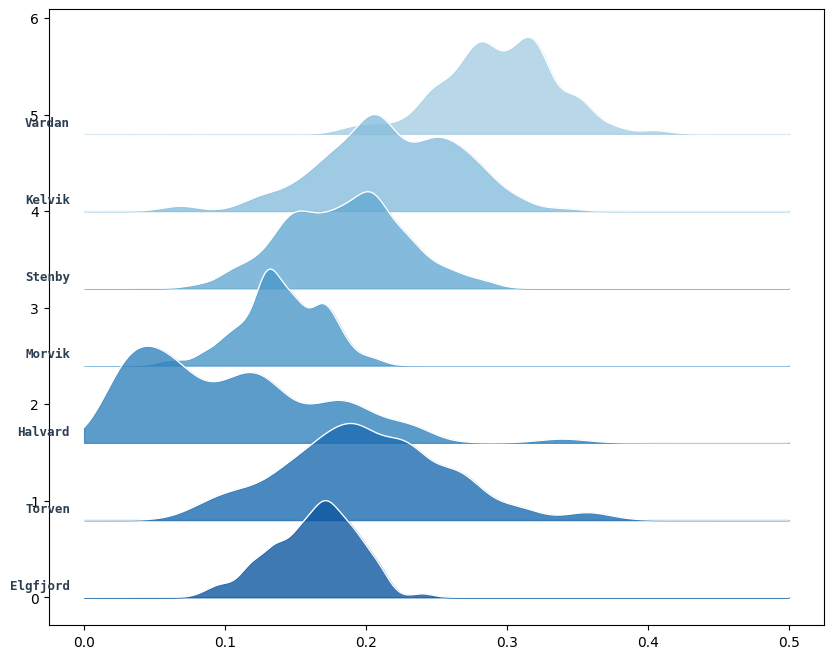

In [5]:
formations_list = list(formations.keys())
n_groups = len(formations_list)
overlap = 0.8

fig, ax = plt.subplots(figsize=(10, 8))
x_range = np.linspace(0, 0.5, 300)
colours = cm.Blues(np.linspace(0.35, 0.85, n_groups))

for i, (name, colour) in enumerate(zip(formations_list, colours)):
  kde = gaussian_kde(formations[name], bw_method=0.25)
  y = kde(x_range)
  y_norm = y / y.max()
  offset = (n_groups - 1 - i) * overlap
  ax.fill_between(x_range, offset, y_norm + offset,
              alpha=0.8, color=colour, zorder=i)
  ax.plot(x_range, y_norm + offset,
        color='white', linewidth=1, zorder=i)
  ax.text(-0.01, offset + 0.05, name,
        ha='right', va='bottom',
        fontsize=9, fontweight='bold',
        fontfamily='monospace', color='#2c3e50')
plt.show()

In [6]:
# Default bandwidth - tends to over-smooth
kde_default = gaussian_kde(formations['Halvard'])

# Narrower bandwidth - preserves more structure
kde_narrow = gaussian_kde(formations['Halvard'], bw_method=0.2)

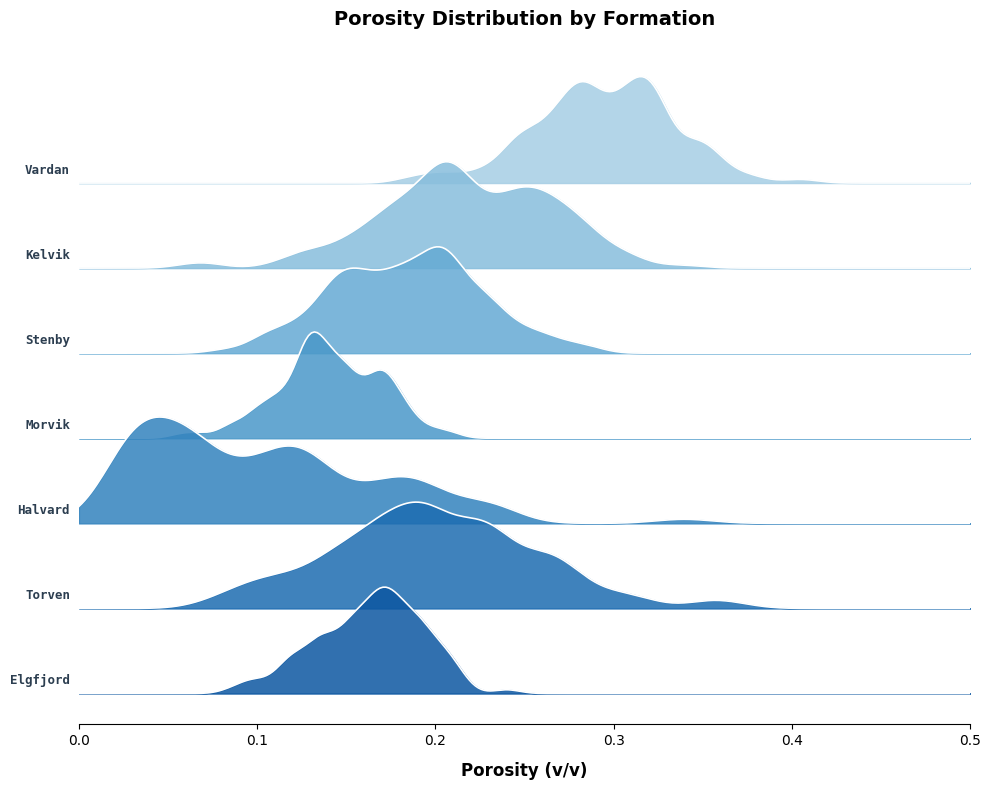

In [7]:
fig, ax = plt.subplots(figsize=(10, 8), facecolor='white')

x_range = np.linspace(0, 0.5, 300)
colours = cm.Blues(np.linspace(0.35, 0.85, n_groups))
overlap = 0.8

for i, (name, colour) in enumerate(zip(formations_list, colours)):
    kde = gaussian_kde(formations[name], bw_method=0.25)
    y = kde(x_range)
    y_norm = y / y.max()
    offset = (n_groups - 1 - i) * overlap
    ax.fill_between(x_range, offset, y_norm + offset,
                    alpha=0.85, color=colour, zorder=i)
    ax.plot(x_range, y_norm + offset,
            color='white', linewidth=1.2, zorder=i)
    ax.text(-0.005, offset + 0.06, name,
            ha='right', va='bottom',
            fontsize=9, fontweight='bold',
            fontfamily='monospace', color='#2c3e50')

ax.set_xlabel('Porosity (v/v)', fontsize=12,
              fontweight='bold', labelpad=10)
ax.set_title('Porosity Distribution by Formation',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlim(0, 0.5)
ax.set_yticks([])
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_visible(True)
ax.tick_params(axis='x', labelsize=10)
plt.tight_layout()
plt.savefig('ridgeline_porosity.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()

,Formation,Porosity
0,Vardan,0.2843
1,Vardan,0.3723
2,Vardan,0.3013
3,Vardan,0.3432
4,Vardan,0.2838
5,Vardan,0.2872
6,Vardan,0.3202
7,Vardan,0.3230
8,Vardan,0.2855
9,Vardan,0.1953


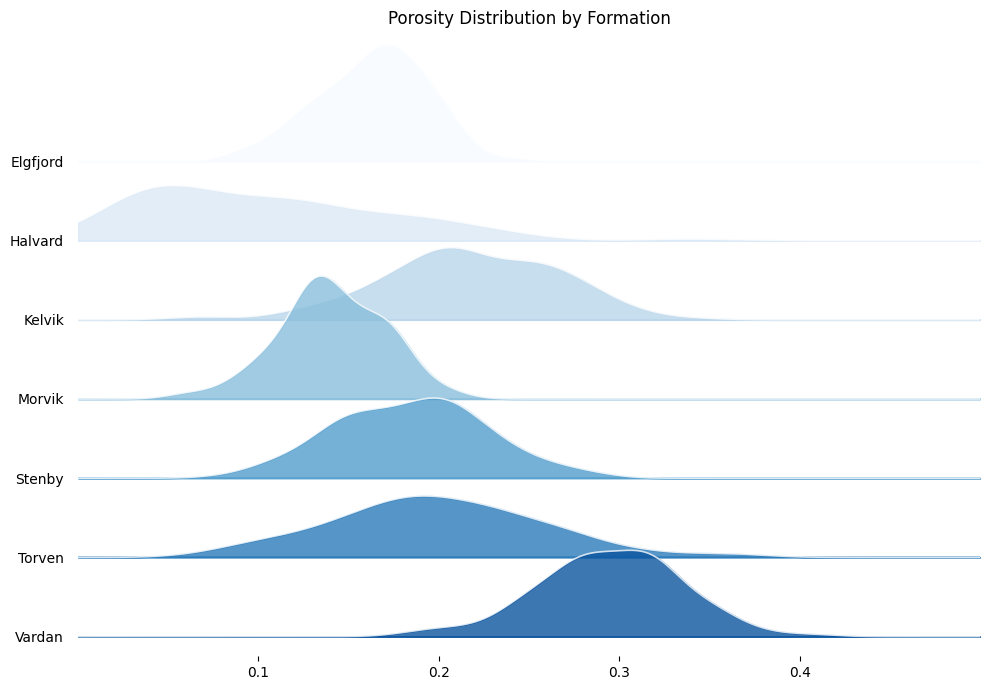

In [8]:
records = []
for name, values in formations.items():
  for v in values:
    records.append({'Formation': name, 'Porosity': v})
df = pd.DataFrame(records)

display(df)

fig, axes = joypy.joyplot(
  df,
  by='Formation',
  column='Porosity',
  figsize=(10, 7),
  colormap=cm.Blues,
  alpha=0.8,
  linecolor='white',
  linewidth=1.2,
  title='Porosity Distribution by Formation',
  x_range=[0, 0.5]
)

```python
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from scipy.stats import gaussian_kde

np.random.seed(99)
formations = {
    'Vardan':   np.random.normal(0.32, 0.04, 120),
    'Kelvik':   np.random.normal(0.22, 0.05, 150),
    'Stenby':   np.random.normal(0.18, 0.04, 130),
    'Morvik':   np.random.normal(0.14, 0.03, 100),
    'Halvard':  np.random.beta(2, 8, 90) * 0.5,
    'Torven':   np.random.normal(0.20, 0.06, 140),
    'Elgfjord': np.random.normal(0.16, 0.03, 110),
}
formations = {k: np.clip(v, 0, 0.5) for k, v in formations.items()}
formations_list = list(formations.keys())
n_groups = len(formations_list)
overlap = 0.8

fig, ax = plt.subplots(figsize=(10, 8), facecolor='white')
x_range = np.linspace(0, 0.5, 300)
colours = cm.Blues(np.linspace(0.35, 0.85, n_groups))

for i, (name, colour) in enumerate(zip(formations_list, colours)):
    kde = gaussian_kde(formations[name], bw_method=0.25)
    y = kde(x_range)
    y_norm = y / y.max()
    offset = (n_groups - 1 - i) * overlap
    ax.fill_between(x_range, offset, y_norm + offset,
                    alpha=0.85, color=colour, zorder=i)
    ax.plot(x_range, y_norm + offset,
            color='white', linewidth=1.2, zorder=i)
    ax.text(-0.005, offset + 0.06, name,
            ha='right', va='bottom',
            fontsize=9, fontweight='bold',
            fontfamily='monospace', color='#2c3e50')

ax.set_xlabel('Porosity (v/v)', fontsize=12, fontweight='bold', labelpad=10)
ax.set_title('Porosity Distribution by Formation',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlim(0, 0.5)
ax.set_yticks([])
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_visible(True)
ax.tick_params(axis='x', labelsize=10)
plt.tight_layout()
plt.savefig('ridgeline_porosity.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
```